<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_SL_Assignment_2_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries and Data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy.stats.mstats import winsorize

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay, recall_score
import numpy as np

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, LinearRegression


from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, mean_squared_error, log_loss


In [10]:
df = pd.read_excel('/content/sample_data/insurance.xlsx')
display(df.head())

,Group,Seq nr,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,Training,1,30,management,married,tertiary,no,1119,no,no,cellular,6,aug,199,7,-1,0,unknown,no
1,Training,2,54,management,married,tertiary,no,-1415,yes,yes,cellular,17,nov,135,1,-1,0,unknown,no
2,Training,3,46,admin.,single,unknown,yes,0,no,no,unknown,23,may,378,2,-1,0,unknown,no
3,Training,4,33,management,married,tertiary,no,2213,no,no,cellular,18,feb,240,1,385,9,failure,no
4,Training,5,52,admin.,married,secondary,no,484,yes,no,unknown,6,may,128,1,-1,0,unknown,no


# Data Pre-Processing

## Feature Engineering

In [11]:
categorical_cols = [col for col in df.select_dtypes(include='object').columns if col not in ['Group', 'Y']]
numerical_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in ['Seq nr', 'age', 'duration']]

# move 'day' from numeric to categorical
moved_to_categorical = ['day']
numerical_cols = [col for col in numerical_cols if col not in moved_to_categorical]
categorical_cols.extend(moved_to_categorical)

# age_group groupings
bins_age = [0, 20, 30, 40, 50, 60, 70, float('inf')]
labels_age = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=False)
df['age_group'] = df['age_group'].replace('<20', '30-39')

# previous adjustments
df['previous_grouped'] = df['previous'].apply(lambda x: 'other' if x > 7 else str(x))
categorical_cols.append('previous_grouped')

# pdays groupings
def group_pdays_custom(pdays_val):
    if pdays_val == -1:
        return '-1 (not contacted)'
    elif pdays_val == 0:
        return '0 days'
    elif 1 <= pdays_val <= 50:
        return '1-50'
    elif 51 <= pdays_val <= 100:
        return '51-100'
    elif 101 <= pdays_val <= 150:
        return '101-150'
    elif 151 <= pdays_val <= 200:
        return '151-200'
    elif 201 <= pdays_val <= 250:
        return '201-250'
    elif 251 <= pdays_val <= 300:
        return '251-300'
    elif 301 <= pdays_val <= 350:
        return '301-350'
    elif 351 <= pdays_val <= 400:
        return '351-400'
    elif pdays_val > 400:
        return '400+'
    else:
        return 'Unknown'

df['pdays_grouped'] = df['pdays'].apply(group_pdays_custom)
categorical_cols.append('pdays_grouped')

# campaign: if a campaign has less than 400 customers in it, group it under "other"
campaign_counts = df['campaign'].value_counts()
campaign_to_other = campaign_counts[campaign_counts < 400].index.tolist()
df['campaign_grouped'] = df['campaign'].apply(lambda x: 'other' if x in campaign_to_other else str(x))
categorical_cols.append('campaign_grouped')


# Add age_group to categorical_cols
categorical_cols.append('age_group')

# Ensure the lists are unique in case of any overlaps
categorical_cols = list(dict.fromkeys(categorical_cols))
numerical_cols = [col for col in numerical_cols if col not in ['previous', 'pdays', 'campaign']]

categorical_cols = [col for col in categorical_cols if col not in ['previous', 'pdays', 'campaign']]

/tmp/ipykernel_2254/4268199803.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['age_group'] = df['age_group'].replace('<20', '30-39')


In [12]:
df['poutcome_grouped'] = df['poutcome'].replace(['other', 'unknown'], 'other_unknown')
categorical_cols = [col for col in categorical_cols if col != 'poutcome']
categorical_cols.append('poutcome_grouped')

# Ensure the lists are unique in case of any overlaps after this change
categorical_cols = list(dict.fromkeys(categorical_cols))

Distributions for Categorical Variables


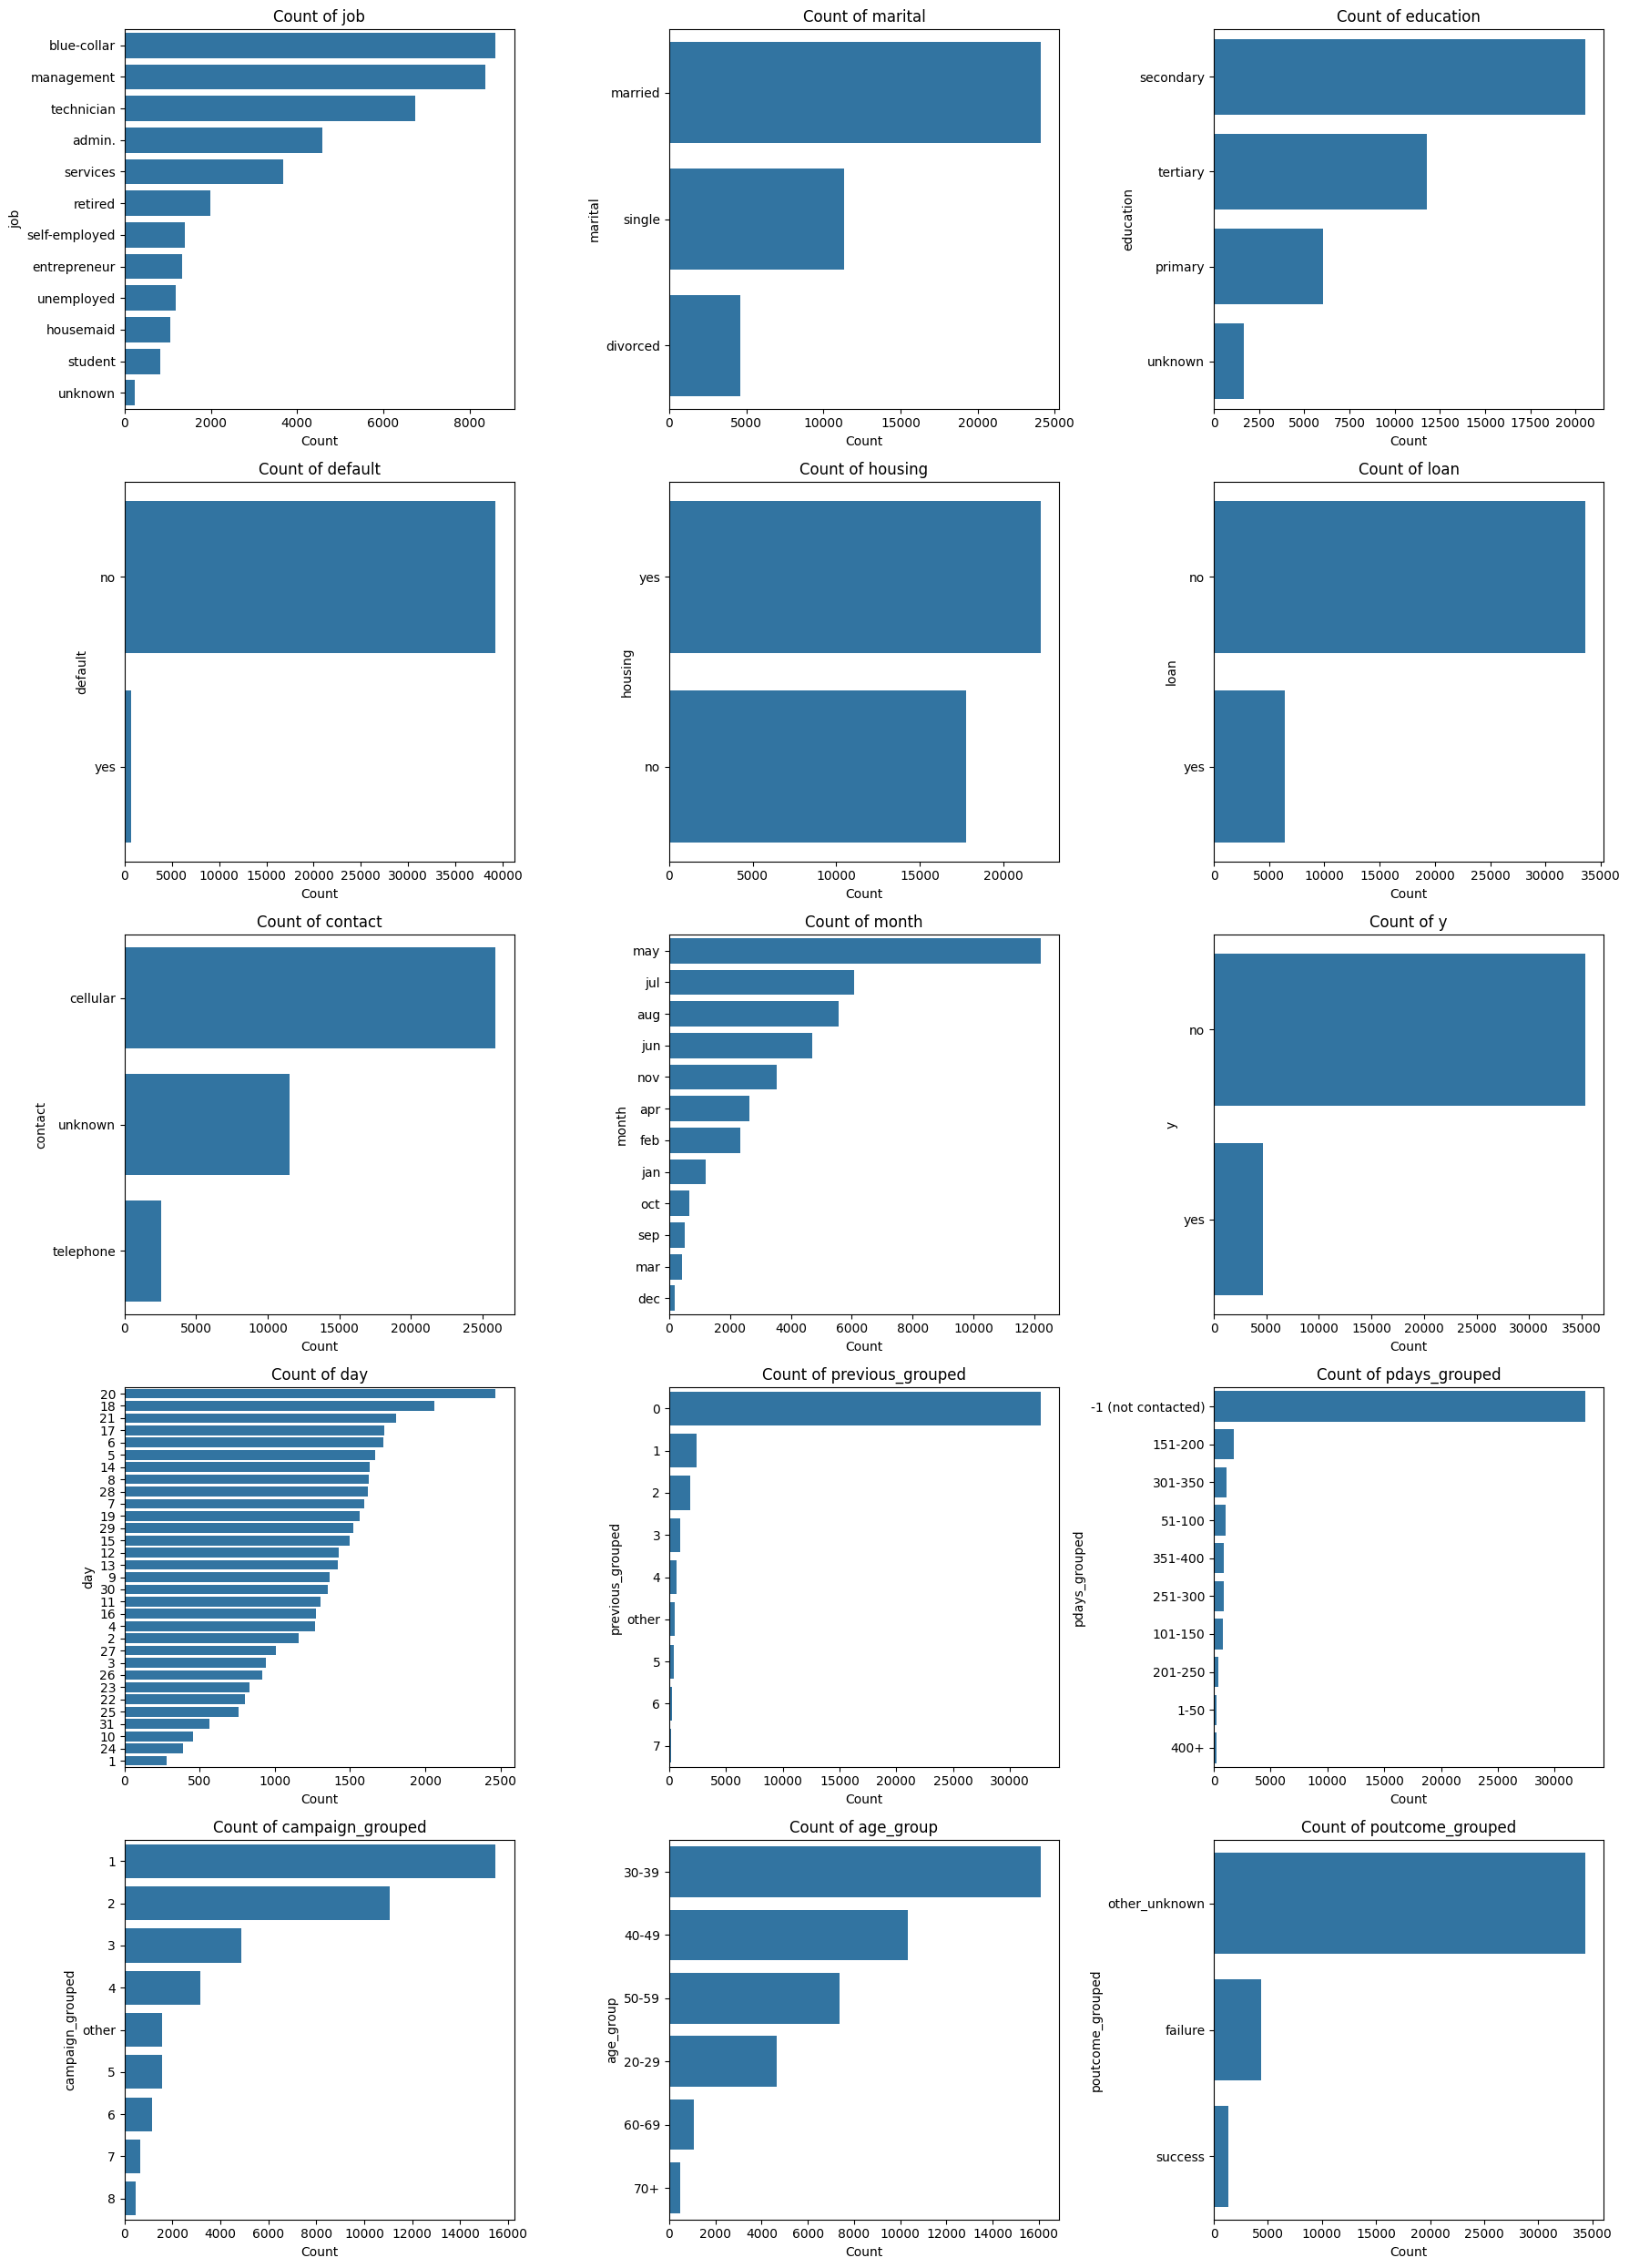

In [13]:
print("Distributions for Categorical Variables")
if categorical_cols:
    n_cat_cols = len(categorical_cols)
    n_cat_rows = (n_cat_cols + 2) // 3
    fig_cat, axes_cat = plt.subplots(n_cat_rows, 3, figsize=(18, 5 * n_cat_rows))
    axes_cat = axes_cat.flatten()

    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, y=col, ax=axes_cat[i], order=df[col].value_counts().index)
        axes_cat[i].set_title(f'Count of {col}')
        axes_cat[i].set_xlabel('Count')
        axes_cat[i].set_ylabel(col)

    for j in range(i + 1, len(axes_cat)):
        fig_cat.delaxes(axes_cat[j])

    plt.tight_layout()
    plt.show()
else:
    print("NA")

Distributions for Numerical Variables


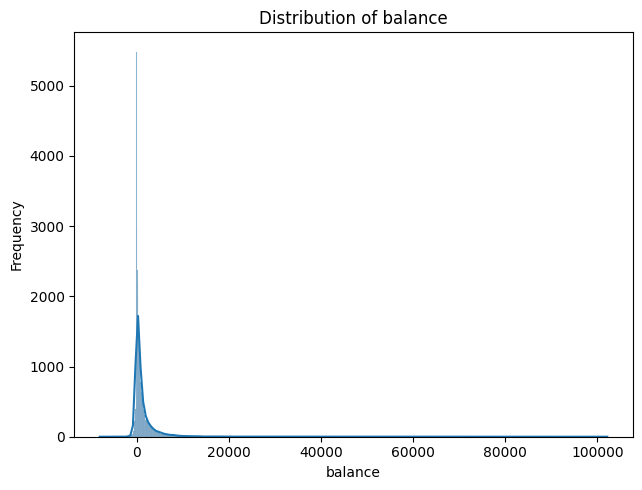

In [14]:
print("Distributions for Numerical Variables")

if numerical_cols:
    n_num_cols = len(numerical_cols)
    n_num_rows = (n_num_cols + 2) // 3
    fig_num, axes_num = plt.subplots(n_num_rows, 3, figsize=(18, 5 * n_num_rows))
    axes_num = axes_num.flatten()

    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes_num[i])
        axes_num[i].set_title(f'Distribution of {col}')
        axes_num[i].set_xlabel(col)
        axes_num[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes_num)):
        fig_num.delaxes(axes_num[j])

    plt.tight_layout()
    plt.show()
else:
    print("NA")

## Scaling

In [15]:
# target vs features
X = df.drop('y', axis=1)
y = df['y']

categorical_features = [col for col in categorical_cols if col != 'y']
numerical_features = numerical_cols

# One-Hot Encode Categorical Variables ---
X_categorical = pd.get_dummies(X[categorical_features], drop_first=True)
print(f"Shape after OHE: {X_categorical.shape}")

# Winsorization to Numerical Variables
X_numerical_processed = X[numerical_features].copy()
X_numerical_processed['balance'] = winsorize(X_numerical_processed['balance'], limits=[0.01, 0.01])

# RobustScaler to Winsorized Numerical Variables
scaler = RobustScaler()
X_numerical_scaled = scaler.fit_transform(X_numerical_processed)

# Convert back
X_numerical_scaled = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=X.index)

# Combine Processed Features
df_processed = pd.concat([X_categorical, X_numerical_scaled], axis=1)

display(df_processed.head())
display(y.head())

Shape after OHE: (40000, 65)


,day,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,campaign_grouped_8,campaign_grouped_other,age_group_30-39,age_group_40-49,age_group_50-59,age_group_60-69,age_group_70+,poutcome_grouped_other_unknown,poutcome_grouped_success,balance
0,6,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,0.499259
1,17,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,-0.794074
2,23,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,-0.329630
3,18,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,1.309630
4,6,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,0.028889


,y
0,no
1,no
2,no
3,no
4,no


## Feature Correlations

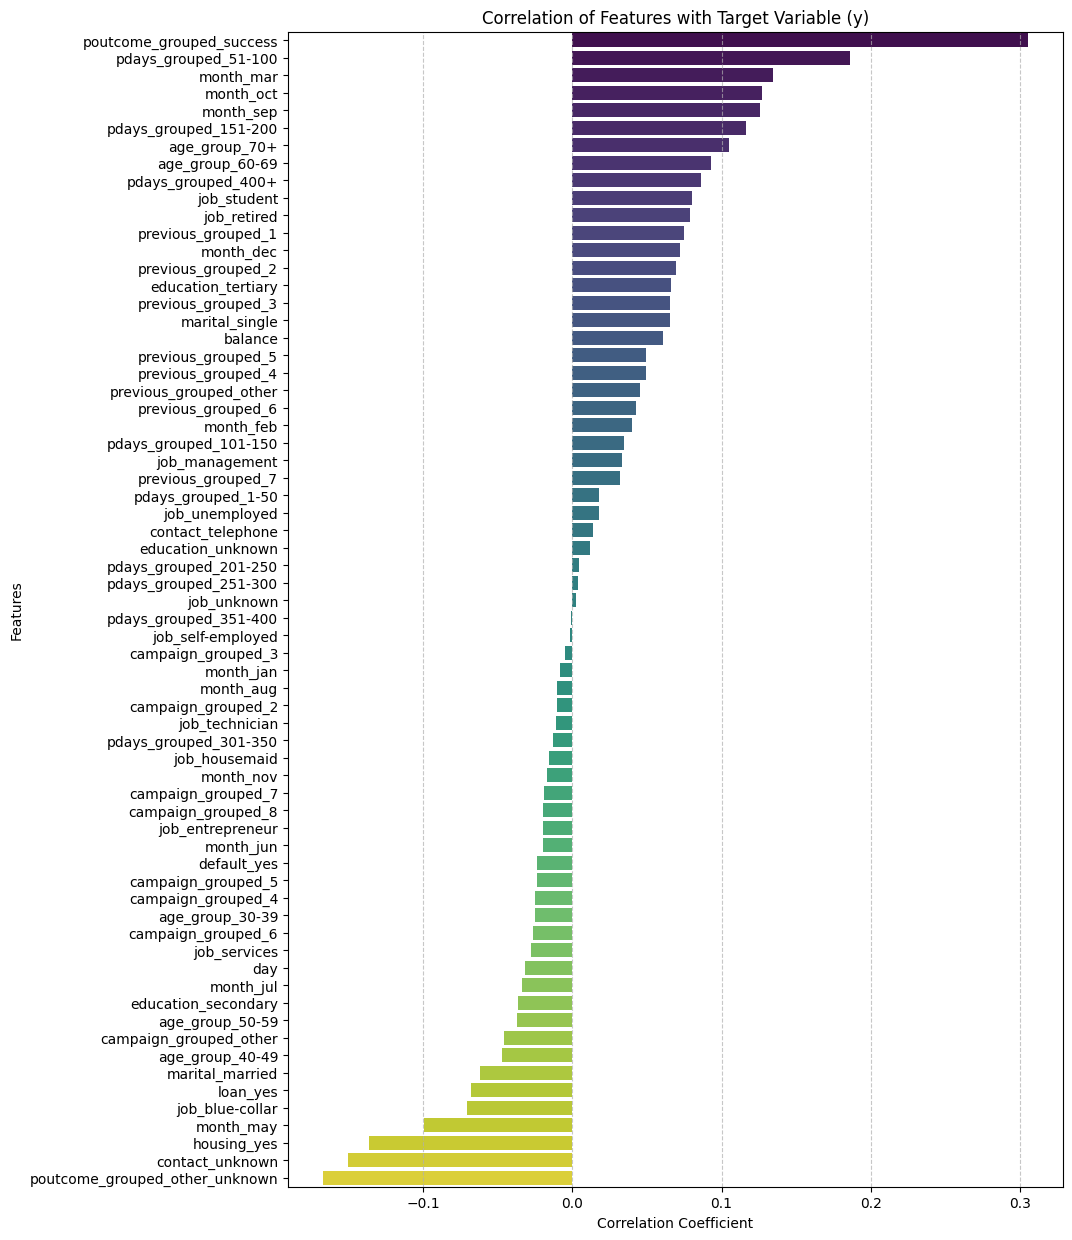

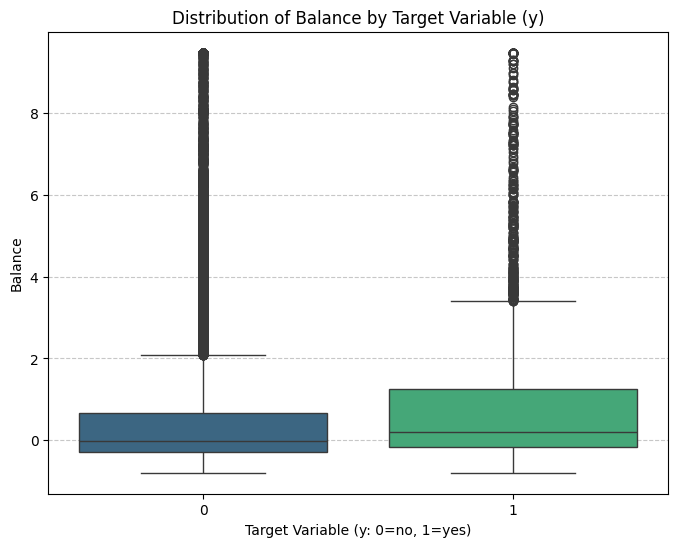

In [16]:
# Map 1 for 'yes', 0 for 'no'
y_numeric = y.map({'yes': 1, 'no': 0})
df_combined = pd.concat([df_processed, y_numeric], axis=1)


correlation_matrix = df_combined.corr()
target_correlations = correlation_matrix['y'].sort_values(ascending=False)
target_correlations = target_correlations.drop('y')

plt.figure(figsize=(10, 15))
sns.barplot(x=target_correlations.values, y=target_correlations.index, palette='viridis', hue=target_correlations.index, legend=False)
plt.title('Correlation of Features with Target Variable (y)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 'balance' vs 'y'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_combined['y'], y=df_combined['balance'], palette='viridis', hue=df_combined['y'], legend=False)
plt.title('Distribution of Balance by Target Variable (y)')
plt.xlabel('Target Variable (y: 0=no, 1=yes)')
plt.ylabel('Balance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Train - Test Split

In [17]:
X_train = df_processed[df['Group'] == 'Training']
X_test = df_processed[df['Group'] == 'Test']
y_train = y[df['Group'] == 'Training']
y_test = y[df['Group'] == 'Test']

# 'yes'/'no' to 1/0
y_train = y_train.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (36000, 66)
Shape of X_test: (4000, 66)
Shape of y_train: (36000,)
Shape of y_test: (4000,)


# Linear Regression

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

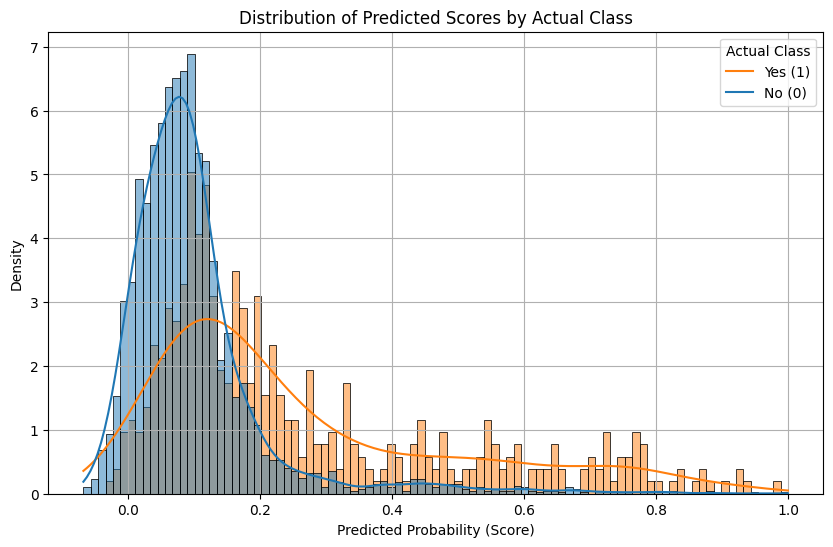

In [20]:
# plotting actual vs. predicted values
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted_Score': y_pred})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='Predicted_Score', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Predicted Scores by Actual Class')
plt.xlabel('Predicted Probability (Score)')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3540
           1       0.57      0.18      0.27       460

    accuracy                           0.89      4000
   macro avg       0.74      0.58      0.60      4000
weighted avg       0.86      0.89      0.86      4000


Confusion Matrix:
[[3479   61]
 [ 379   81]]


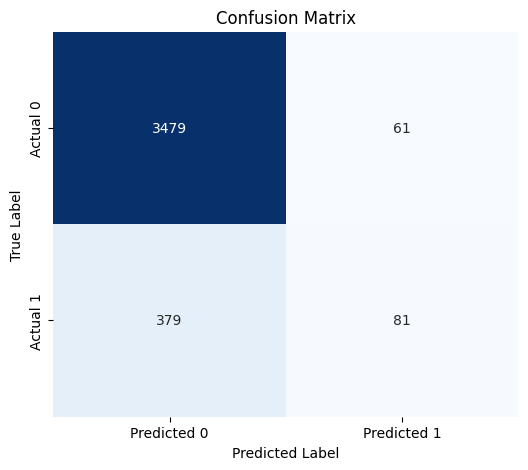

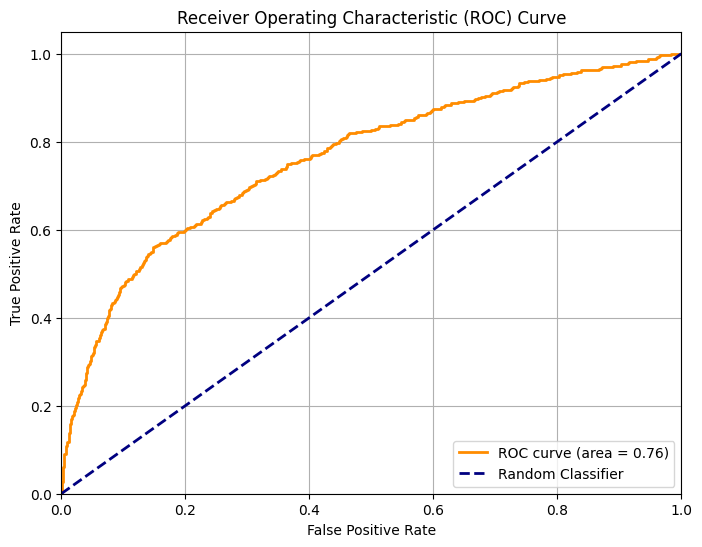


AUC Score: 0.76


In [21]:
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# AUC-ROC Chart
# For ROC curve, y_pred (continuous probabilities/scores) are used directly
if len(np.unique(y_test)) == 2 and np.sum(y_test) > 0 and np.sum(y_test == 0) > 0:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print(f"\nAUC Score: {roc_auc:.2f}")
else:
    print("NA")


In [22]:
# Get the coefficients and their corresponding feature names
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients_df['Absolute_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df = coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Model Coefficients (sorted by absolute value):")
display(coefficients_df)

Model Coefficients (sorted by absolute value):


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,0.404139,0.404139
48,pdays_grouped_400+,0.256805,0.256805
28,month_mar,0.236904,0.236904
25,month_jan,-0.130004,0.130004
49,pdays_grouped_51-100,0.120647,0.120647
...,...,...,...
65,balance,0.004114,0.004114
7,job_services,-0.002967,0.002967
13,marital_single,-0.001863,0.001863
4,job_management,-0.000980,0.000980


## Logistic Regression with class_weight='balanced'

In [23]:
logistic_model_balanced = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced')
logistic_model_balanced.fit(X_train, y_train)

y_pred_proba_logistic_balanced = logistic_model_balanced.predict_proba(X_test)[:, 1]
y_pred_proba_logistic_balanced_train = logistic_model_balanced.predict_proba(X_train)[:, 1]

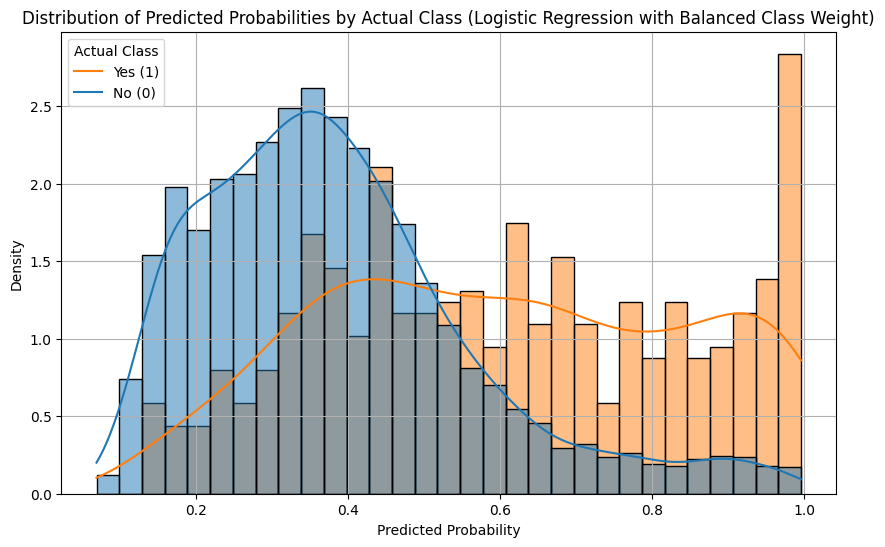

In [24]:
plot_df_logistic_balanced = pd.DataFrame({'Actual': y_test, 'Predicted_Probability': y_pred_proba_logistic_balanced})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df_logistic_balanced, x='Predicted_Probability', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Predicted Probabilities by Actual Class (Logistic Regression with Balanced Class Weight)')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()


Logistic Regression (Balanced Class Weight) Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      3540
           1       0.28      0.62      0.39       460

    accuracy                           0.78      4000
   macro avg       0.61      0.71      0.63      4000
weighted avg       0.87      0.78      0.81      4000


Logistic Regression (Balanced Class Weight) Confusion Matrix:
[[2814  726]
 [ 173  287]]


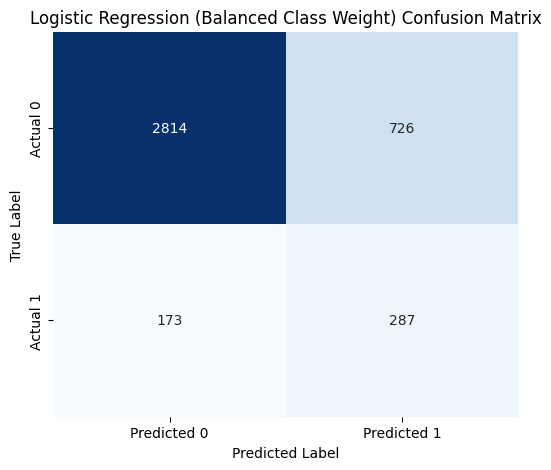

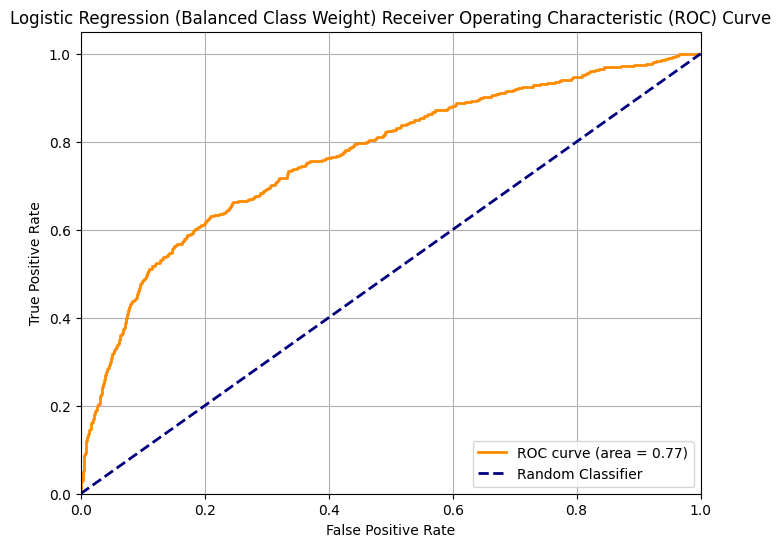


Logistic Regression (Balanced Class Weight) AUC Score: 0.77


In [25]:
# Convert probabilities to binary predictions using a threshold of 0.5
y_pred_binary_logistic_balanced = (y_pred_proba_logistic_balanced > 0.5).astype(int)

# Classification Report
print("\nLogistic Regression (Balanced Class Weight) Classification Report:")
print(classification_report(y_test, y_pred_binary_logistic_balanced))

#Confusion Matrix
cm_logistic_balanced = confusion_matrix(y_test, y_pred_binary_logistic_balanced)
print("\nLogistic Regression (Balanced Class Weight) Confusion Matrix:")
print(cm_logistic_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logistic_balanced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression (Balanced Class Weight) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# AUC-ROC Chart
if len(np.unique(y_test)) == 2 and np.sum(y_test) > 0 and np.sum(y_test == 0) > 0:
    fpr_logistic_balanced, tpr_logistic_balanced, thresholds_logistic_balanced = roc_curve(y_test, y_pred_proba_logistic_balanced)
    roc_auc_logistic_balanced = auc(fpr_logistic_balanced, tpr_logistic_balanced)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logistic_balanced, tpr_logistic_balanced, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_logistic_balanced:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Logistic Regression (Balanced Class Weight) Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print(f"\nLogistic Regression (Balanced Class Weight) AUC Score: {roc_auc_logistic_balanced:.2f}")
else:
    print("NA")

In [26]:
coefficients_df_logistic_balanced = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model_balanced.coef_[0]
})

coefficients_df_logistic_balanced['Absolute_Coefficient'] = abs(coefficients_df_logistic_balanced['Coefficient'])
coefficients_df_logistic_balanced = coefficients_df_logistic_balanced.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nLogistic Regression (Balanced Class Weight) Model Coefficients (sorted by absolute value):")
display(coefficients_df_logistic_balanced)


Logistic Regression (Balanced Class Weight) Model Coefficients (sorted by absolute value):


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,2.084236,2.084236
48,pdays_grouped_400+,1.851628,1.851628
28,month_mar,1.233507,1.233507
21,contact_unknown,-1.232491,1.232491
25,month_jan,-1.077712,1.077712
...,...,...,...
5,job_retired,0.021641,0.021641
27,month_jun,0.020733,0.020733
33,previous_grouped_1,-0.006642,0.006642
41,pdays_grouped_1-50,-0.002530,0.002530


# Bootstrap

In [27]:
n_iterations = 200

print(" Bootstrapping for Logistic Regression (class_weight='balanced')")
intercepts_logistic_balanced = []

X_train_combined_logistic = X_train.copy()
X_train_combined_logistic['target'] = y_train.values

for i in range(n_iterations):
    sample_df_logistic = X_train_combined_logistic.sample(n=len(X_train_combined_logistic), replace=True, random_state=i)

    X_sample_logistic = sample_df_logistic.drop('target', axis=1)
    y_sample_logistic = sample_df_logistic['target']

    bootstrap_model_logistic = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced')
    bootstrap_model_logistic.fit(X_sample_logistic, y_sample_logistic)

    intercepts_logistic_balanced.append(bootstrap_model_logistic.intercept_[0])

confidence_interval_logistic_balanced = np.percentile(intercepts_logistic_balanced, [2.5, 97.5])
print(f"Logistic Regression (Balanced) Bootstrap 95% CI for Intercept: {confidence_interval_logistic_balanced}")

 Bootstrapping for Logistic Regression (class_weight='balanced')
Logistic Regression (Balanced) Bootstrap 95% CI for Intercept: [0.72935509 1.31903085]


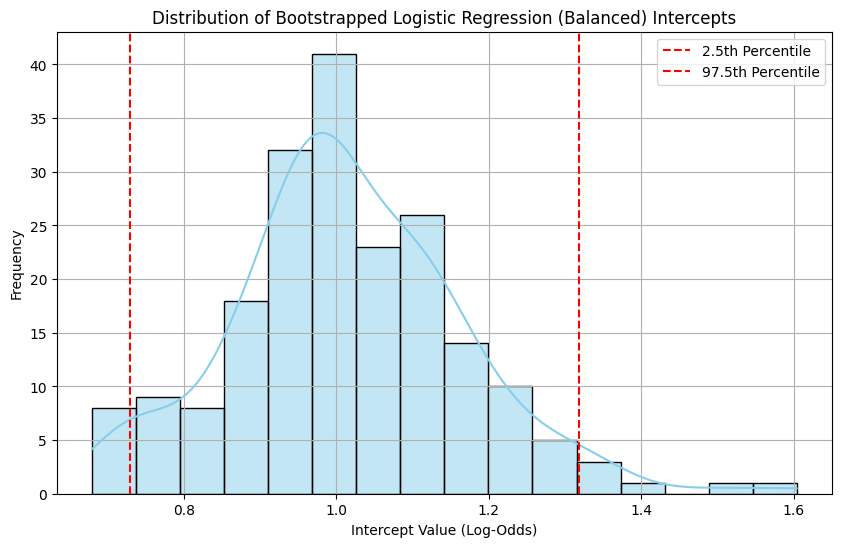

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(intercepts_logistic_balanced, kde=True, color='skyblue')
plt.title('Distribution of Bootstrapped Logistic Regression (Balanced) Intercepts')
plt.xlabel('Intercept Value (Log-Odds)')
plt.ylabel('Frequency')
plt.axvline(confidence_interval_logistic_balanced[0], color='red', linestyle='--', label='2.5th Percentile')
plt.axvline(confidence_interval_logistic_balanced[1], color='red', linestyle='--', label='97.5th Percentile')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
intercepts_linear = []

X_train_combined_linear = X_train.copy()
X_train_combined_linear['target'] = y_train.values

for i in range(n_iterations):
    sample_df_linear = X_train_combined_linear.sample(n=len(X_train_combined_linear), replace=True, random_state=i)

    X_sample_linear = sample_df_linear.drop('target', axis=1)
    y_sample_linear = sample_df_linear['target']

    bootstrap_model_linear = LinearRegression()
    bootstrap_model_linear.fit(X_sample_linear, y_sample_linear)

    intercepts_linear.append(bootstrap_model_linear.intercept_)

confidence_interval_linear = np.percentile(intercepts_linear, [2.5, 97.5])
print(f"Linear Regression Bootstrap 95% CI for Intercept: {confidence_interval_linear}")

Linear Regression Bootstrap 95% CI for Intercept: [0.19717123 0.26141383]


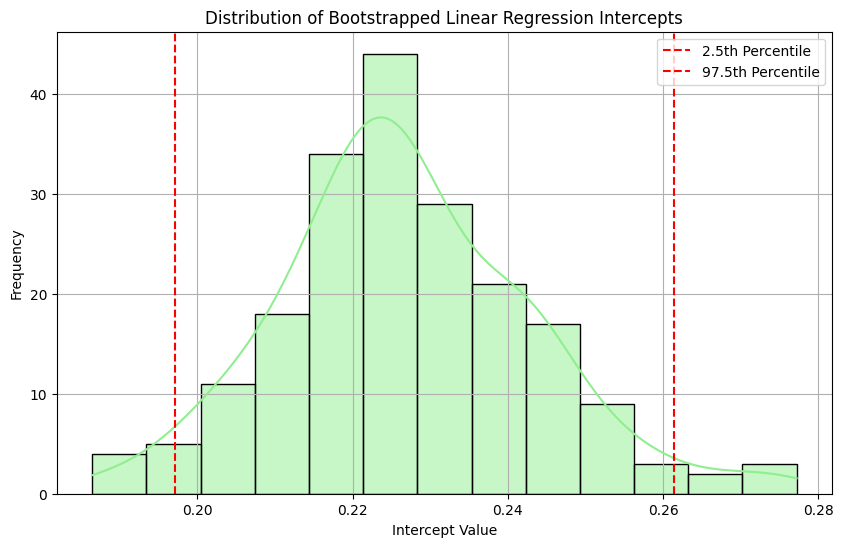

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(intercepts_linear, kde=True, color='lightgreen')
plt.title('Distribution of Bootstrapped Linear Regression Intercepts')
plt.xlabel('Intercept Value')
plt.ylabel('Frequency')
plt.axvline(confidence_interval_linear[0], color='red', linestyle='--', label='2.5th Percentile')
plt.axvline(confidence_interval_linear[1], color='red', linestyle='--', label='97.5th Percentile')
plt.legend()
plt.grid(True)
plt.show()


-Platt Scaling
Original Brier Score for Logistic Regression (Balanced): 0.1831
Brier Score for Logistic Regression (Balanced) after Platt Scaling: 0.0888
Original Mean Squared Error for Logistic Regression (Balanced): 0.1831
Mean Squared Error for Logistic Regression (Balanced) after Platt Scaling: 0.0888
Original Log Loss for Logistic Regression (Balanced): 0.5658
Log Loss for Logistic Regression (Balanced) after Platt Scaling: 0.3062


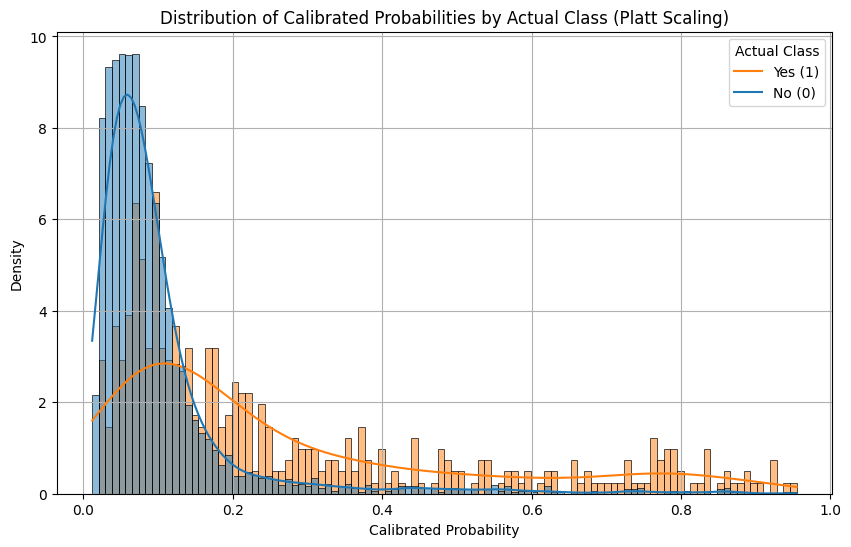

In [40]:
print("\n-Platt Scaling")

unfitted_logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced')

platt_calibrator = CalibratedClassifierCV(unfitted_logistic_model, method='sigmoid', cv=5)
platt_calibrator.fit(X_train, y_train)

y_pred_proba_platt_calibrated = platt_calibrator.predict_proba(X_test)[:, 1]

brier_logistic_balanced = brier_score_loss(y_test, y_pred_proba_logistic_balanced)
brier_platt_calibrated = brier_score_loss(y_test, y_pred_proba_platt_calibrated)

mse_logistic_balanced = mean_squared_error(y_test, y_pred_proba_logistic_balanced)
mse_platt_calibrated = mean_squared_error(y_test, y_pred_proba_platt_calibrated)


logloss_logistic_balanced = log_loss(y_test, np.clip(y_pred_proba_logistic_balanced, epsilon, 1 - epsilon))
logloss_platt_calibrated = log_loss(y_test, np.clip(y_pred_proba_platt_calibrated, epsilon, 1 - epsilon))

print(f"Original Brier Score for Logistic Regression (Balanced): {brier_logistic_balanced:.4f}")
print(f"Brier Score for Logistic Regression (Balanced) after Platt Scaling: {brier_platt_calibrated:.4f}")

print(f"Original Mean Squared Error for Logistic Regression (Balanced): {mse_logistic_balanced:.4f}")
print(f"Mean Squared Error for Logistic Regression (Balanced) after Platt Scaling: {mse_platt_calibrated:.4f}")

print(f"Original Log Loss for Logistic Regression (Balanced): {logloss_logistic_balanced:.4f}")
print(f"Log Loss for Logistic Regression (Balanced) after Platt Scaling: {logloss_platt_calibrated:.4f}")

# Visualize the calibrated probabilities distribution
plot_df_platt_calibrated = pd.DataFrame({'Actual': y_test, 'Calibrated_Probability': y_pred_proba_platt_calibrated})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df_platt_calibrated, x='Calibrated_Probability', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Calibrated Probabilities by Actual Class (Platt Scaling)')
plt.xlabel('Calibrated Probability')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()

### Reliability Diagram (Calibration Plot)

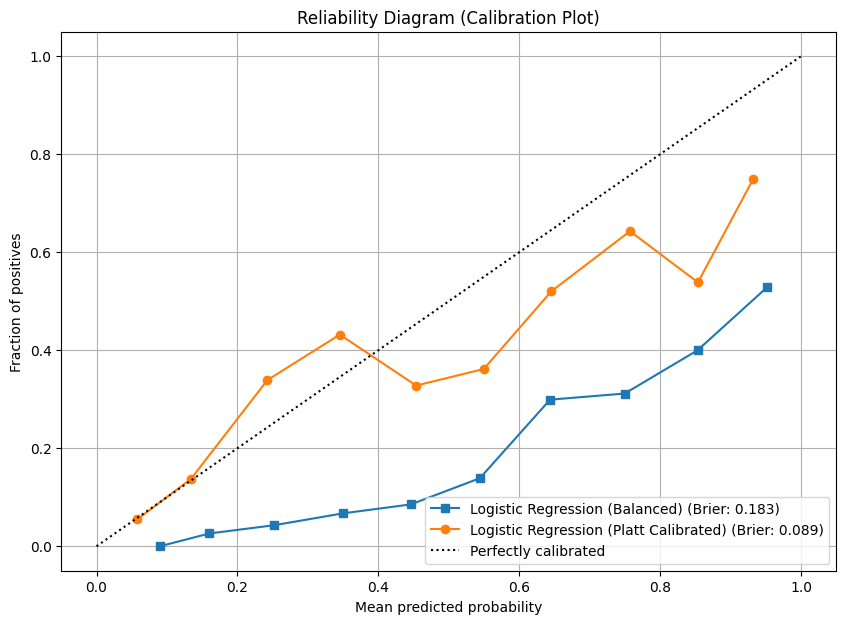

In [34]:
from sklearn.calibration import calibration_curve

# Reliability diagram for original Logistic Regression (Balanced)
fraction_of_positives_logistic, mean_predicted_value_logistic = calibration_curve(
    y_test, y_pred_proba_logistic_balanced, n_bins=10
)

# Reliability diagram for Platt-calibrated Logistic Regression
fraction_of_positives_platt, mean_predicted_value_platt = calibration_curve(
    y_test, y_pred_proba_platt_calibrated, n_bins=10
)

plt.figure(figsize=(10, 7))
plt.plot(mean_predicted_value_logistic, fraction_of_positives_logistic, "s-",
         label=f"Logistic Regression (Balanced) (Brier: {brier_logistic_balanced:.3f})")
plt.plot(mean_predicted_value_platt, fraction_of_positives_platt, "o-",
         label=f"Logistic Regression (Platt Calibrated) (Brier: {brier_platt_calibrated:.3f})")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability Diagram (Calibration Plot)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Precision-Recall Curves Comparison

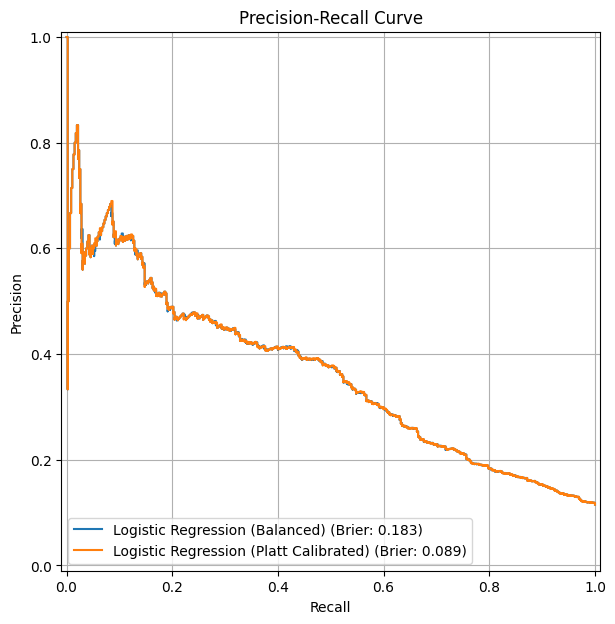

In [35]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

# Calculate Precision-Recall for original Logistic Regression (Balanced)
precision_logistic, recall_logistic, _ = precision_recall_curve(
    y_test, y_pred_proba_logistic_balanced
)

# Calculate Precision-Recall for Platt-calibrated Logistic Regression
precision_platt, recall_platt, _ = precision_recall_curve(
    y_test, y_pred_proba_platt_calibrated
)

plt.figure(figsize=(10, 7))
disp_logistic = PrecisionRecallDisplay(precision=precision_logistic, recall=recall_logistic)
disp_logistic.plot(ax=plt.gca(), name=f"Logistic Regression (Balanced) (Brier: {brier_logistic_balanced:.3f})")

disp_platt = PrecisionRecallDisplay(precision=precision_platt, recall=recall_platt)
disp_platt.plot(ax=plt.gca(), name=f"Logistic Regression (Platt Calibrated) (Brier: {brier_platt_calibrated:.3f})")

plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()